In [8]:
from tensorflow.keras import backend as K
K.clear_session()

In [9]:
!pip install rarfile

In [10]:
import os
import pandas as pd
import gdown
import rarfile
import shutil
from PIL import Image
# Download the RAR file
url = 'https://drive.google.com/uc?id=1QpuuKjhpL_9KiNp-tqdcahBPmX5ojgS0'
#https://drive.google.com/file/d/1QpuuKjhpL_9KiNp-tqdcahBPmX5ojgS0/view?usp=drive_link
output_rar = '/content/Plant_Drone_Dataset.rar'
gdown.download(url, output_rar, quiet=False)
# Extract the RAR file
with rarfile.RarFile(output_rar, 'r') as rar_ref:
    rar_ref.extractall('/content')

Downloading...
From (original): https://drive.google.com/uc?id=1QpuuKjhpL_9KiNp-tqdcahBPmX5ojgS0
From (redirected): https://drive.google.com/uc?id=1QpuuKjhpL_9KiNp-tqdcahBPmX5ojgS0&confirm=t&uuid=b881d0ed-4d80-4c24-90ad-5f118aa67d50
To: /content/Plant_Drone_Dataset.rar
100%|██████████| 358M/358M [00:07<00:00, 48.3MB/s]


In [11]:
# Path to the extracted dataset folder

dataset = '/content/Plant_Drone_Dataset'

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, Input, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
import numpy as np
import os

def dense_block(x, blocks, name):
    """A dense block"""
    for i in range(blocks):
        x = conv_block(x, 32, name=name + '_block' + str(i + 1))
    return x

def transition_block(x, reduction, name):
    """A transition block"""
    bn_axis = 3 if tf.keras.backend.image_data_format() == 'channels_last' else 1
    x = tf.keras.layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5,
                                  name=name + '_bn')(x)
    x = tf.keras.layers.Activation('swish', name=name + '_swish')(x)
    x = tf.keras.layers.Conv2D(int(tf.keras.backend.int_shape(x)[bn_axis] * reduction), 1,
                      use_bias=False,
                      name=name + '_conv')(x)
    x = tf.keras.layers.AveragePooling2D(2, strides=2, name=name + '_pool')(x)
    return x

def conv_block(x, growth_rate, name):
    """A building block for a dense block"""
    bn_axis = 3 if tf.keras.backend.image_data_format() == 'channels_last' else 1
    x1 = tf.keras.layers.BatchNormalization(axis=bn_axis,
                                   epsilon=1.001e-5,
                                   name=name + '_0_bn')(x)
    x1 = tf.keras.layers.Activation('swish', name=name + '_0_swish')(x1)
    x1 = tf.keras.layers.Conv2D(4 * growth_rate, 1,
                       use_bias=False,
                       name=name + '_1_conv')(x1)
    x1 = tf.keras.layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5,
                                  name=name + '_1_bn')(x1)
    x1 = tf.keras.layers.Activation('swish', name=name + '_1_swish')(x1)
    x1 = tf.keras.layers.Conv2D(growth_rate, 3,
                       padding='same',
                       use_bias=False,
                       name=name + '_2_conv')(x1)
    x = tf.keras.layers.Concatenate(axis=bn_axis, name=name + '_concat')([x, x1])
    return x

def DenseNet(blocks, input_shape, num_classes=5):
    img_input = tf.keras.layers.Input(shape=input_shape)

    bn_axis = 3 if tf.keras.backend.image_data_format() == 'channels_last' else 1

    x = tf.keras.layers.ZeroPadding2D(padding=((3, 3), (3, 3)))(img_input)
    x = tf.keras.layers.Conv2D(64, 7, strides=2, use_bias=False, name='conv1_conv')(x)
    x = tf.keras.layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name='conv1_bn')(x)
    x = tf.keras.layers.Activation('swish', name='conv1_swish')(x)
    x = tf.keras.layers.ZeroPadding2D(padding=((1, 1), (1, 1)))(x)
    x = tf.keras.layers.MaxPooling2D(3, strides=2, name='pool1')(x)

    x = dense_block(x, blocks[0], name='conv2')
    x = transition_block(x, 0.5, name='pool2')
    x = dense_block(x, blocks[1], name='conv3')
    x = transition_block(x, 0.5, name='pool3')
    x = dense_block(x, blocks[2], name='conv4')
    x = transition_block(x, 0.5, name='pool4')
    x = dense_block(x, blocks[3], name='conv5')

    x = tf.keras.layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name='bn')(x)
    x = tf.keras.layers.Activation('swish', name='swish')(x)

    x = tf.keras.layers.GlobalAveragePooling2D(name='avg_pool')(x)
    x = tf.keras.layers.Dense(num_classes, activation='softmax', name='fc1000')(x)

    model = tf.keras.models.Model(img_input, x, name='densenet')

    return model

model = DenseNet([6, 12, 48, 32],
                 input_shape=(224, 224, 3),
                 num_classes=4)

# Show model summary
model.summary()

Model: "densenet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_swish         │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_swish[0][0] │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_swi… │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_s… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_swi… │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_s… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_swi… │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_s

 Total params: 18,329,668 (69.92 MB)

 Trainable params: 18,100,612 (69.05 MB)

 Non-trainable params: 229,056 (894.75 KB)

Found 5742 images belonging to 4 classes.
Found 957 images belonging to 4 classes.
Found 1595 images belonging to 4 classes.
Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


180/180 ━━━━━━━━━━━━━━━━━━━━ 787s 2s/step - accuracy: 0.9429 - loss: 0.1518 - val_accuracy: 0.2424 - val_loss: 6.6277
Epoch 2/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 86s 474ms/step - accuracy: 0.9923 - loss: 0.0220 - val_accuracy: 0.2424 - val_loss: 13.4528
Epoch 3/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 87s 481ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.3271 - val_loss: 5.1582
Epoch 4/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 87s 482ms/step - accuracy: 0.9999 - loss: 4.2973e-04 - val_accuracy: 0.8830 - val_loss: 0.2375
Epoch 5/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 87s 481ms/step - accuracy: 0.9988 - loss: 0.0045 - val_accuracy: 0.7712 - val_loss: 0.6168
Epoch 6/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 87s 483ms/step - accuracy: 0.9918 - loss: 0.0310 - val_accuracy: 0.9394 - val_loss: 0.1797
Epoch 7/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 87s 482ms/step - accuracy: 0.9995 - loss: 0.0017 - val_accuracy: 0.8234 - val_loss: 0.4521
Epoch 8/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 87s 482ms/step - accuracy: 1.0000 - loss: 9.0242e-0

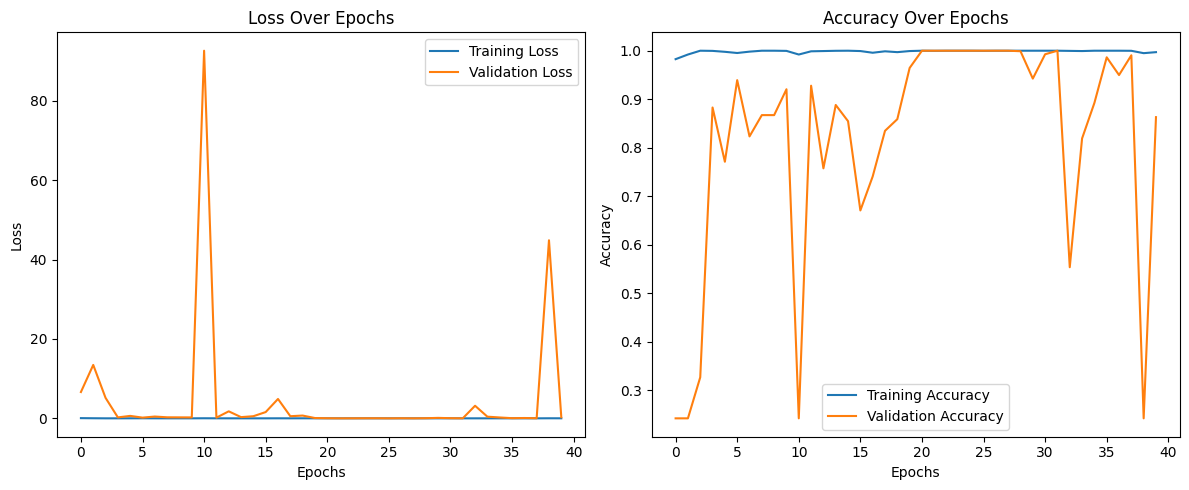

50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 757ms/step

Performance on Test Data
Precision: 0.9476365611038433
Recall: 0.9347962382445141
F1 Score: 0.9328739124298278
Accuracy: 0.9347962382445141
Confusion Matrix:
                                 acacia modesta (phulai)  \
acacia modesta (phulai)                             246   
ailanthus altissima (Bahishti)                        0   
bauhinia variegata (kachnar)                          0   
pinus roxburghii (chir)                               0   

                                ailanthus altissima (Bahishti)  \
acacia modesta (phulai)                                    100   
ailanthus altissima (Bahishti)                             406   
bauhinia variegata (kachnar)                                 0   
pinus roxburghii (chir)                                      2   

                                bauhinia variegata (kachnar)  \
acacia modesta (phulai)                                    0   
ailanthus altissima (Bahishti)             

In [13]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Add,
    GlobalAveragePooling2D, Flatten, Dense
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Directory for the dataset
data_dir = dataset

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Data generators for training, validation, and testing
train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'Train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(data_dir, 'Validate'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, 'Test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# Training the model
history = model.fit(train_generator, epochs=40, validation_data=val_generator)

# Plot training results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Helper function to evaluate the model on given test generator
def evaluate_model(test_generator, model, classes, title="Performance"):
    y_test_pred = model.predict(test_generator)
    y_test_pred = np.argmax(y_test_pred, axis=1)

    precision = precision_score(test_generator.labels, y_test_pred, average='weighted')
    recall = recall_score(test_generator.labels, y_test_pred, average='weighted')
    f1 = f1_score(test_generator.labels, y_test_pred, average='weighted')
    accuracy = accuracy_score(test_generator.labels, y_test_pred)

    print(f"\n{title}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Accuracy:", accuracy)

    # Display the confusion matrix
    confusion = confusion_matrix(test_generator.labels, y_test_pred)
    confusion_df = pd.DataFrame(confusion, index=classes, columns=classes)
    print("Confusion Matrix:\n", confusion_df)

# Test the model on the test set
evaluate_model(test_generator, model, ['acacia modesta (phulai)', 'ailanthus altissima (Bahishti)', 'bauhinia variegata (kachnar)', 'pinus roxburghii (chir)'], title="Performance on Test Data")

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step
Confusion Matrix:
                                 acacia modesta (phulai)  \
acacia modesta (phulai)                             246   
ailanthus altissima (Bahishti)                        0   
bauhinia variegata (kachnar)                          0   
pinus roxburghii (chir)                               0   

                                ailanthus altissima (Bahishti)  \
acacia modesta (phulai)                                    100   
ailanthus altissima (Bahishti)                             406   
bauhinia variegata (kachnar)                                 0   
pinus roxburghii (chir)                                      2   

                                bauhinia variegata (kachnar)  \
acacia modesta (phulai)                                    0   
ailanthus altissima (Bahishti)                             0   
bauhinia variegata (kachnar)                             406   
pinus roxburghii (chir)                                  

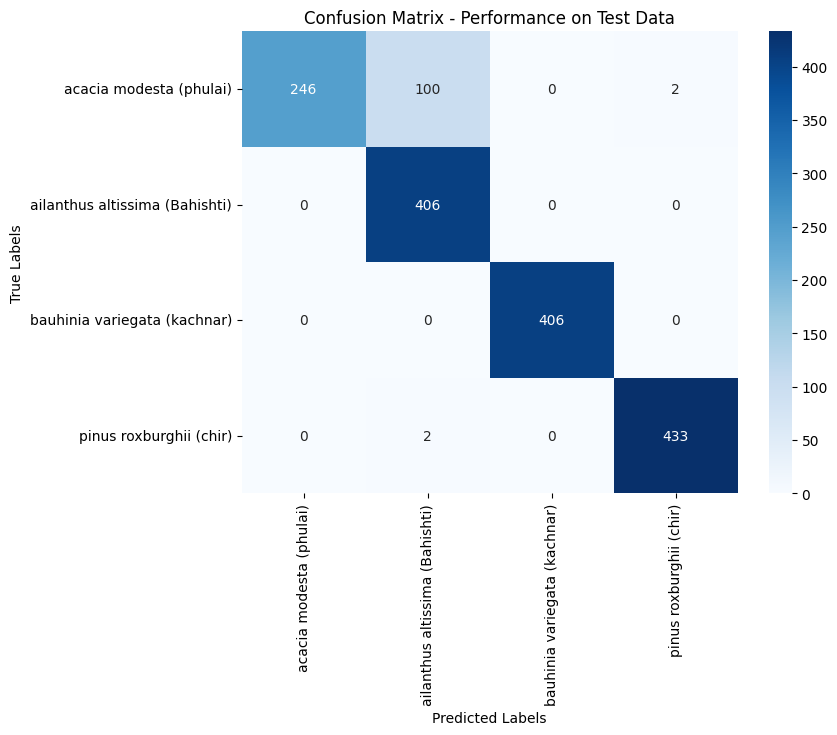

In [15]:
# Add this import at the beginning of your code
import seaborn as sns

# Generate and display the heatmap for the confusion matrix
labels = [
    'acacia modesta (phulai)', 'ailanthus altissima (Bahishti)', 'bauhinia variegata (kachnar)', 'pinus roxburghii (chir)'
]

# Predict on test data
y_test_pred = model.predict(test_generator)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

# Calculate the confusion matrix
confusion = confusion_matrix(test_generator.labels, y_test_pred_classes)

# Convert confusion matrix to a DataFrame for better readability
confusion_df = pd.DataFrame(confusion, index=labels, columns=labels)

# Print the confusion matrix
print("Confusion Matrix:\n", confusion_df)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_df, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix - Performance on Test Data')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()